In [38]:
import numpy as np

from fenics import *
from typing import Optional
from numpy.typing import NDArray
from utils.utils import progress_bar
from algorithms.matrix_free_rsvd import MatrixFreeRSVD
import matplotlib.pyplot as plt
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W, tikhonov_solver
from utils.mesh_utils import get_square_f
from utils.colors import C2, C3, C5, CMAP

SEED = 15

In [213]:
class LowRankCGSolver:
    def __init__(
            self,
            mfrsvd: MatrixFreeRSVD,
            x_true: Optional[NDArray] = None
        ) -> None:
        """
        Initialize the ProjectedLowRankSolver.

        mfrsvd, MatrixFreeRSVD: A trained MatrixFreeRSVD objected.
        x_true, optional: True x source, to track the error while training.
        """
        self.V_h = mfrsvd.V_h
        self.M_dx = mfrsvd.M_dx
        self.M_ds = mfrsvd.M_ds
        self.U = mfrsvd.Uk
        self.S = mfrsvd.Sk
        self.VT = mfrsvd.VkT
        self.UT = self.U.T
        self.V = self.VT.T
        self.x_true = x_true

        # Set up vec to matrix and matrix to vec utils
        coords = self.V_h.tabulate_dof_coordinates()
        self.grid_indices = np.lexsort((coords[:, 0], coords[:, 1]))
        self.dof_indices = np.argsort(self.grid_indices)
        self.n = int(np.sqrt(self.V_h.dim()))

    def matrix_to_vec(self, X: NDArray) -> NDArray:
        return X.flatten()[self.dof_indices]

    def vec_to_matrix(self, x: NDArray) -> NDArray:
        return x[self.grid_indices].reshape((self.n, self.n))

    def apply_H(self, P, w, lambda_, mask, rho):
        """
        Computes H * P, where H is the Hessian of the quadratic cost function.
        Here, H = K^T M_ds K + lambda * W^T M W
        """
        p = self.matrix_to_vec(P)
        Kp = self.U @ (self.S * (self.VT @ p))

        # Compute (K^T M_ds K)p and (lambda * W^T M W)p
        H_data = self.V @ (self.S * (self.UT @ (self.M_ds @ Kp)))
        H_reg = lambda_ * (w * (self.M_dx @ (w * p)))

        # Penalize negative terms
        if rho > 0:
            H_pos = rho * (mask * p)
            return self.vec_to_matrix(H_data + H_reg + H_pos)

        return self.vec_to_matrix(H_data + H_reg)

    def solve(
            self,
            y,
            w,
            lambda_=1e-4,
            rho=0.0,
            max_iter=100,
            max_rank=5,
            seed=None
        ):
        # Initialize X and its SVD
        X = self.initial_X(seed)
        Ux, sx, VxT = np.linalg.svd(X, full_matrices=False)
        Vx = VxT.T
        Sx = np.diag(sx)

        # Initialize gradient G and search direction D
        x = self.matrix_to_vec(X)
        mask = (x < 0).astype(float)
        G, _ = self.gradient(x, y, w, lambda_, rho)
        D = -G.copy()
        
        for i in range(1, max_iter + 1):
            # Step size
            HD = self.apply_H(D, w, lambda_, mask=mask, rho=rho)
            alpha = np.sum(G * G) / np.sum(D * HD)

            # W-step
            W_star = (Ux @ Sx) + alpha * (D @ Vx)
            U_hat, _ = np.linalg.qr(np.hstack([Ux, W_star]))

            # L-ste
            L_star = (Vx @ Sx.T) + alpha * (D.T @ Ux)
            V_hat, _ = np.linalg.qr(np.hstack([Vx, L_star]))

            # S-step
            S_new = (U_hat.T @ Ux) @ Sx @ (Vx.T @ V_hat)
            S_new = S_new + alpha * (U_hat.T @ D @ V_hat)

            # Truncate back to low-rank
            Ux, Sx, Vx = self.truncate(U_hat, S_new, V_hat, 0.01, max_rank)
            VxT = Vx.T
            
            # Update the gradient and the search direction
            denom = np.sum(G * G)
            G = G + alpha * HD
            beta = np.sum(G * G) / denom
            D = -G + beta * D

            # Compute mask for negativity penalty
            if rho > 0:
                x = self.matrix_to_vec(Ux @ Sx @ VxT)
                mask = (x < 0).astype(float)
            
            progress_bar(i, max_iter)

        return self.matrix_to_vec(Ux @ Sx @ VxT)
    
    def initial_X(self, seed):
        rng = np.random.default_rng(seed)
        X = rng.random((self.n, self.n)) * 1e-3
        return X
    
    def gradient(self, x, y, w, lambda_, rho=0.0):
            """
            Given the SVD X = U S V^T, compute the gradient of the cost
            function Phi with respect to X.
            """
            # Compute the gradient D
            r = self.U @ (self.S * (self.VT @ x)) - y
            grad_data = self.V @ (self.S * (self.UT @ (self.M_ds @ r)))
            grad_reg = lambda_ * (w * (self.M_dx @ (w * x)))
            grad = grad_data + grad_reg

            # Punish negative elements
            if rho > 0:
                negative_parts = np.minimum(x, 0) # Non-zero only where X < 0
                grad_positivity = rho * negative_parts
                grad += grad_positivity

            D = self.vec_to_matrix(grad)
            return D, r
    
    def truncate(self, U1, S, V1, tol, max_rank=1):
        """
        Truncates according to tolerance
        U1: (m x k) left factor
        S:  (k x k) matrix to re-SVD (can be diagonal or full)
        V1: (n x k) right factor
        tol: scalar tolerance (same semantics as original: relative factor multiplied by norm(S))
        Returns: (U1_trunc, S_trunc, V1_trunc)
        """

        U_s, s_vals, Vh = np.linalg.svd(S, full_matrices=False)
        # convert singular values to a 1D array (s_vals already is)
        tol = tol * np.linalg.norm(S)

        # cumulative tail-sum test (Julia used sqrt(sum(...)^2) which equals abs(sum(...)))
        rmax = s_vals.size
        retained = rmax  # default keep all
        for j in range(rmax):  # 0-based index
            tail_sum = np.sum(s_vals[j:rmax])
            if abs(tail_sum) < tol:
                retained = j
                break

        if max_rank is not None:
            retained = min(retained, int(max_rank))

        # Truncation / rotate factors
        U1 = U1 @ U_s
        V1 = V1 @ Vh.T

        S_trunc = np.diag(s_vals[:retained])
        U1_trunc = U1[:, :retained]
        V1_trunc = V1[:, :retained]

        return U1_trunc, S_trunc, V1_trunc

    def apply_H2(self, P, w, lambda_, rho, X_curr):
        """
        Computes H * P.
        H_total = H_data + H_reg + H_positivity
        """
        p = self.matrix_to_vec(P)
        x_vec = self.matrix_to_vec(X_curr)
        
        # Original Data term
        Kp = self.U @ (self.S * (self.VT @ p))
        H_data = self.V @ (self.S * (self.UT @ (self.M_ds @ Kp)))
        
        # Original Regularization term
        H_reg = lambda_ * (w * (self.M_dx @ (w * p)))

        # Positivity Penalty term: rho * P (but only where X is negative)
        # This is the 'curvature' of the penalty
        mask = (x_vec < 0).astype(float)
        H_pos = rho * (mask * p)
        return self.vec_to_matrix(H_data + H_reg + H_pos)

    def solve2(
            self,
            y,
            w,
            lambda_=1e-4,
            rho=1e3, # Added penalty parameter
            max_iter=100,
            max_rank=5,
            seed=None
        ):
        X = self.initial_X(seed)
        Ux, Sx_mat, Vx = np.linalg.svd(X, full_matrices=False)
        Sx_mat = np.diag(Sx_mat)
        
        for i in range(1, max_iter + 1):
            X_curr = Ux @ Sx_mat @ Vx.T
            #print(X.shape, X_curr.shape)
            # 1. Direct Gradient calculation (more stable for penalty)
            G, _ = self.gradient(self.matrix_to_vec(X_curr), y, w, lambda_, rho)
            
            if i == 1:
                D = -G.copy()
                rs_old = np.sum(G * G)
            else:
                # 2. Beta / Search Direction update
                rs_new = np.sum(G * G)
                beta = rs_new / rs_old
                
                # Periodic Restart (every 10 steps) to handle non-quadratic penalty
                if i % 10 == 0: beta = 0
                
                D = -G + beta * D
                rs_old = rs_new

            # 3. Step size calculation
            HD = self.apply_H2(D, w, lambda_, rho, X_curr)
            denom = np.sum(D * HD)
            alpha = rs_old / denom

            # 4. Low-Rank Manifold Steps (Standard)
            W_star = (Ux @ Sx_mat) + alpha * (D @ Vx)
            U_hat, _ = np.linalg.qr(np.hstack([Ux, W_star]))

            L_star = (Vx @ Sx_mat.T) + alpha * (D.T @ Ux)
            V_hat, _ = np.linalg.qr(np.hstack([Vx, L_star]))

            S_new = (U_hat.T @ Ux) @ Sx_mat @ (Vx.T @ V_hat) + alpha * (U_hat.T @ D @ V_hat)

            # 5. Truncate
            Ux, Sx_mat, Vx = self.truncate(U_hat, S_new, V_hat, 0.01, max_rank)
            
            progress_bar(i, max_iter)

        return self.matrix_to_vec(Ux @ Sx_mat @ Vx.T)

In [201]:
def problem_setup(n, k):
    mesh = UnitSquareMesh(n, n)
    V_h = FunctionSpace(mesh, 'CG', 1)

    mfrsvd = MatrixFreeRSVD(V_h)
    x0, y0, width, height = 0.1, 0.7, 0.15, 0.15
    f = get_square_f(V_h, x0, y0, w=width, h=height)
    x = f.vector().get_local()
    y = mfrsvd.apply_K(x)

    # Approximate SVD K = U S V^T and weights W
    Uk, Sk, VkT = mfrsvd.mf_rsvd(k=k, seed=SEED)
    w = get_approximate_W(VkT.T, mfrsvd.M_dx)
    return V_h, y, x, f, w, mfrsvd


V_h, y, x, f, w, mfrsvd = problem_setup(n=64, k=25)

print(mfrsvd.N_b, mfrsvd.N)

256 4225


[##############################] 1000/1000


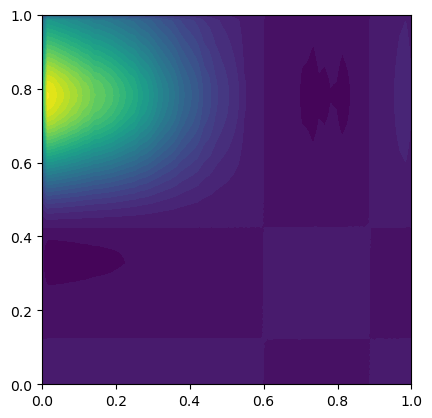

In [214]:
solver = LowRankCGSolver(mfrsvd, x)
x_hat = solver.solve2(y, w,
    lambda_=2e-7,
    max_iter=1000,
    max_rank=1,
    rho=0
)
f_hat = Function(V_h)
f_hat.vector()[:] = x_hat
plot(f_hat)



[##############################] 50/50
[##############################] 50/50
[##############################] 50/50


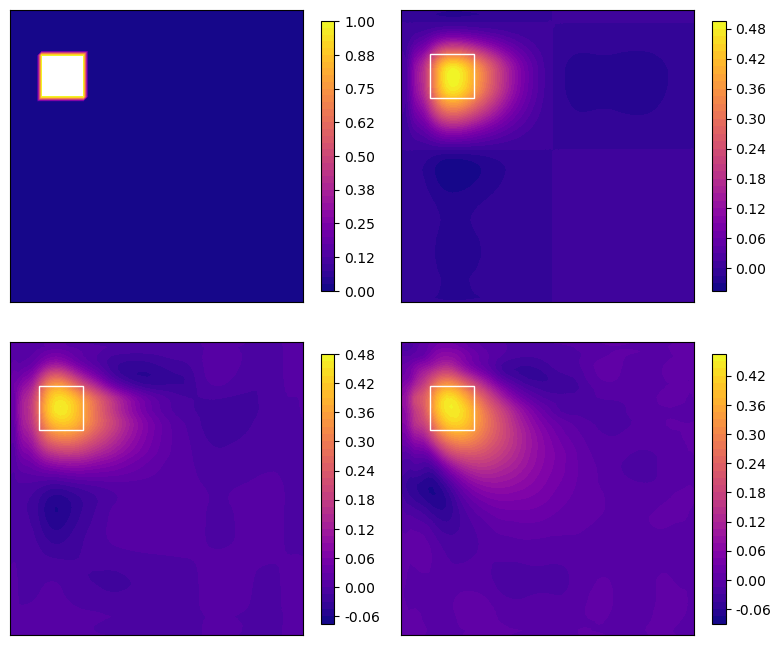

In [173]:
def plot_solutions(f_list, fig_name=None, x0_list=None, y0_list=None, width=0.15, height=0.15):
    import matplotlib.patches as patches
    fig, axes = plt.subplots(2, 2, figsize=(8, 7))
    axes = axes.flatten()

    for i, (ax, fi) in enumerate(zip(axes, f_list)):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP)

        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.8)
        ax.set_xticks([])
        ax.set_yticks([])
 
        # Plot square
        if i != 0 and x0_list is not None:
            for x0, y0 in zip(x0_list, y0_list):
                square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
                ax.add_patch(square)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.07)
    if fig_name is not None:
        plt.savefig(f'../figures/{fig_name}', dpi=300, bbox_inches='tight')
    plt.show()

    plt.show()

solver = LowRankCGSolver(mfrsvd, x)

f_list = [f]
for mr in [1, 2, 15]:
    x_hat = solver.solve(y, w,
        lambda_=2e-7,
        max_iter=50,
        max_rank=mr,
        rho=1e-4
    )
    f_hat = Function(V_h)
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)


x0_list, y0_list = [0.1], [0.7]
plot_solutions(f_list, x0_list=x0_list, y0_list=y0_list)

---

In [144]:
def get_source(V_h, x0_list, y0_list, width, height):
    x = np.zeros(V_h.dim())
    for x0, y0 in zip(x0_list, y0_list):
        f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
        x += f.vector().get_local()

    f = Function(V_h)
    f.vector()[:] = x
    return f, x


def problem_setup2(n, k):
    mesh = UnitSquareMesh(n, n)
    V_h = FunctionSpace(mesh, 'CG', 1)

    mfrsvd = MatrixFreeRSVD(V_h)
    # Make x and y
    x0s = [0.1, 0.75, 0.15]
    y0s = [0.1, 0.75, 0.65]
    f, x = get_source(V_h, x0s, y0s, 0.15, 0.15)
    y = mfrsvd.apply_K(x)

    # Approximate SVD K = U S V^T and weights W
    Uk, Sk, VkT = mfrsvd.mf_rsvd(k=k, seed=SEED)
    w = get_approximate_W(VkT.T, mfrsvd.M_dx)
    return V_h, y, x, f, w, mfrsvd, x0s, y0s

V_h, y, x, f, w, mfrsvd, x0s, y0s = problem_setup2(n=48, k=25)


[##############################] 50/50
[##############################] 50/50
[##############################] 50/50


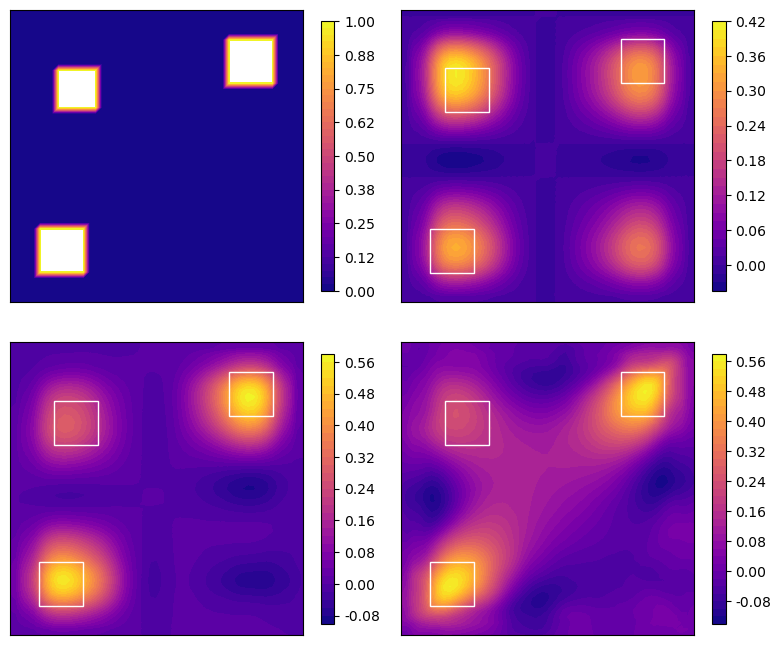

In [145]:
solver = LowRankCGSolver(mfrsvd, x)

f_list = [f]
for mr in [1, 2, 15]:
    x_hat = solver.solve(y, w,
        lambda_=2e-7,
        max_iter=50,
        max_rank=mr,
    )
    f_hat = Function(V_h)
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)

plot_solutions(f_list, x0_list=x0s, y0_list=y0s)